# Experimento 3 — Registro de embeddings: rendimiento y calidad

**Objetivo**: Documentar el proceso de **registro** de personas (generación de embeddings) y medir su **rendimiento** (tiempos) y su **calidad** (qué tan bien se reconoce a la persona después).

## Qué mide este notebook
1. **Tiempos de registro** corriendo el pipeline de `src/embedding_db.py` instrumentado: por persona se mide cantidad de fotos de entrada, embeddings generados con éxito, fotos fallidas (con la razón del fallo) y tiempo total / por imagen.
2. **Calidad de la base:** distancias **intra-persona** (misma persona) vs **inter-persona** (personas distintas), para ver si la base separa a la gente y dónde queda el umbral de 0.6.
3. **¿Cuántas fotos bastan? (suficiencia)** — prueba de reconocimiento *held-out*: se registra con N fotos y se reconoce las que **no** se usaron, en función de N.
4. **¿Conviene la variedad?** — comparar un registro de **solo frontales** vs uno **variado** (perfil, accesorios, iluminación) y ver cuál reconoce mejor las caras difíciles.

## Salidas
- `experiments/resultados_exp3.csv` — tabla de tiempos por persona.
- `experiments/resultados_exp3_suficiencia.csv` — reconocimiento vs cantidad de fotos.
- `experiments/resultados_exp3_variedad.csv` — frontal vs variado.
- `experiments/resultados_exp3_por_foto.csv` — detalle por foto (éxito/fallo, tiempo).
- Gráficos en `experiments/graphs/`.

## 1. Setup

Importa dependencias, ubica la raíz del proyecto y carga el detector YOLO **una sola vez** (su carga es costosa). El detector y `face_recognition` son exactamente los que usa `src/embedding_db.py`.

In [1]:
# Imports y configuracion de rutas
import sys
import time
import pickle
from pathlib import Path
from itertools import combinations

import cv2
import numpy as np
import pandas as pd
import face_recognition
import matplotlib.pyplot as plt

# Ubicar la raiz del proyecto subiendo hasta encontrar la carpeta src/
RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

from src.detector import FaceDetector

RUTA_DATASET = RAIZ / "dataset" / "known_faces"
RUTA_MODELO_YOLO = RAIZ / "models" / "yolov8n-face.pt"
RUTA_EMBEDDINGS = RAIZ / "embeddings.pkl"
RUTA_GRAPHS = RAIZ / "experiments" / "graphs"
RUTA_GRAPHS.mkdir(parents=True, exist_ok=True)

print("Raiz del proyecto :", RAIZ)
print("Dataset           :", RUTA_DATASET, "| existe:", RUTA_DATASET.exists())
print("Modelo YOLO       :", RUTA_MODELO_YOLO, "| existe:", RUTA_MODELO_YOLO.exists())

# Cargar el detector una sola vez (la carga del modelo es costosa)
detector = FaceDetector(str(RUTA_MODELO_YOLO), conf_threshold=0.5)
print("\nDetector YOLO cargado correctamente.")

Raiz del proyecto : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial
Dataset           : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\dataset\known_faces | existe: True
Modelo YOLO       : c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\models\yolov8n-face.pt | existe: True

Detector YOLO cargado correctamente.


## 2. Corrida de registro (pipeline de `embedding_db.py` instrumentado)

La función `procesar_persona` reproduce **paso a paso** el pipeline de `src/embedding_db.py` (`EmbeddingDB.generar`), pero instrumentado para medir el **tiempo por imagen** y registrar la **razón de cada fallo**:

1. Cargar imagen BGR con OpenCV.
2. Detectar rostros con YOLO y quedarse con el de mayor confianza.
3. Convertir coordenadas `(x1,y1,x2,y2)` → `(top,right,bottom,left)`.
4. Convertir BGR → RGB.
5. Generar el embedding de 128-d con `face_recognition.face_encodings`.

Razones de fallo posibles: *imagen ilegible*, *YOLO no detectó rostro*, *face_recognition no generó embedding*.

In [2]:
def listar_fotos(carpeta):
    """Devuelve las fotos (jpg/jpeg/png) de una carpeta, ordenadas por nombre."""
    return sorted(
        f for f in carpeta.glob("*")
        if f.suffix.lower() in (".jpg", ".jpeg", ".png")
    )


def procesar_persona(rutas_fotos):
    """Reproduce el pipeline de src/embedding_db.py, instrumentado.

    Mide el tiempo de cada foto, genera su embedding y registra el
    resultado (exito) o la razon del fallo.

    Returns:
        registros: lista de dicts por foto (archivo, exito, razon_fallo, tiempo_ms).
        embeddings: lista de vectores np.ndarray (128-d) de las fotos exitosas.
    """
    registros = []
    embeddings = []
    for ruta in rutas_fotos:
        t0 = time.perf_counter()
        exito = False
        razon = ""

        # Cargar imagen BGR
        img = cv2.imread(str(ruta))
        if img is None:
            razon = "imagen ilegible (cv2.imread devolvio None)"
        else:
            # Detectar rostros con YOLO
            dets = detector.detect(img)
            if not dets:
                razon = "YOLO no detecto rostro"
            else:
                # Mejor deteccion por confianza -> coordenadas
                x1, y1, x2, y2, _ = max(dets, key=lambda d: d[4])
                loc = (y1, x2, y2, x1)  # (top, right, bottom, left)
                # BGR -> RGB
                rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Embedding de 128-d
                enc = face_recognition.face_encodings(
                    rgb, known_face_locations=[loc]
                )
                if not enc:
                    razon = "face_recognition no genero embedding"
                else:
                    embeddings.append(enc[0])
                    exito = True

        dt_ms = (time.perf_counter() - t0) * 1000
        registros.append({
            "archivo": ruta.name,
            "exito": exito,
            "razon_fallo": razon,
            "tiempo_ms": round(dt_ms, 1),
        })
    return registros, embeddings

print("Funciones listas: listar_fotos(), procesar_persona().")

Funciones listas: listar_fotos(), procesar_persona().


In [3]:
personas = sorted(p for p in RUTA_DATASET.iterdir() if p.is_dir())
print("Personas encontradas:", [p.name for p in personas], "\n")

registros_todos = []          # una fila por foto
embeddings_por_persona = {}   # {persona: [emb, ...]}
tiempo_por_persona = {}       # {persona: segundos}

t_global = time.perf_counter()
for carpeta in personas:
    nombre = carpeta.name
    fotos = listar_fotos(carpeta)
    t0 = time.perf_counter()
    regs, embs = procesar_persona(fotos)
    tiempo_por_persona[nombre] = time.perf_counter() - t0
    embeddings_por_persona[nombre] = embs
    for r in regs:
        r["persona"] = nombre
        registros_todos.append(r)
    print(f"  {nombre:10s}: {len(fotos):2d} fotos -> {len(embs):2d} embeddings "
          f"({len(fotos) - len(embs)} fallidas) en {tiempo_por_persona[nombre]:.2f}s")

tiempo_total = time.perf_counter() - t_global
print(f"\nTiempo total de registro: {tiempo_total:.2f}s")

df_fotos = pd.DataFrame(
    registros_todos,
    columns=["persona", "archivo", "exito", "razon_fallo", "tiempo_ms"],
)
df_fotos.head()

Personas encontradas: ['gerardo', 'kevin', 'miguel'] 

  gerardo   : 15 fotos -> 15 embeddings (0 fallidas) en 15.54s
  kevin     : 21 fotos -> 21 embeddings (0 fallidas) en 11.03s
  miguel    : 15 fotos -> 15 embeddings (0 fallidas) en 5.40s

Tiempo total de registro: 31.97s


,persona,archivo,exito,razon_fallo,tiempo_ms
0,gerardo,gerardo_accesorioCapucha_01.jpg,True,,1533.0
1,gerardo,gerardo_accesorioCapuchaLentes_01.jpg,True,,1377.4
2,gerardo,gerardo_accesorioLentes_01.jpg,True,,1033.2
3,gerardo,gerardo_accesorioLentes_02.jpg,True,,1042.3
4,gerardo,gerardo_contraluz_01.jpg,True,,1011.9


In [4]:
# Guardar la base en el mismo formato que src/embedding_db.py: {nombre: [emb, ...]}
emb_db = {n: e for n, e in embeddings_por_persona.items() if e}
with open(RUTA_EMBEDDINGS, "wb") as f:
    pickle.dump(emb_db, f)

print(f"embeddings.pkl guardado: {RUTA_EMBEDDINGS}")
print(f"  Tamano: {RUTA_EMBEDDINGS.stat().st_size / 1024:.1f} KB")
print(f"  Personas: {len(emb_db)}\n")

# Verificar que todos los vectores sean de dimension 128
print("Verificacion de dimensiones:")
for n, e in emb_db.items():
    print(f"  {n:10s}: {len(e):2d} embeddings de dimension {len(e[0])}")

embeddings.pkl guardado: c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\embeddings.pkl
  Tamano: 52.8 KB
  Personas: 3

Verificacion de dimensiones:
  gerardo   : 15 embeddings de dimension 128
  kevin     : 21 embeddings de dimension 128
  miguel    : 15 embeddings de dimension 128


In [5]:
# (Opcional) Ejecutar el modulo oficial src/embedding_db.py tal cual.
# Genera embeddings.pkl + fallidos.txt e imprime su propio resumen.
# Se deja DESACTIVADO para no recomputar YOLO (la corrida instrumentada de
# arriba ya produjo la misma base). Cambiar a True si se quiere ejecutar.
EJECUTAR_MODULO_OFICIAL = False

if EJECUTAR_MODULO_OFICIAL:
    from src.embedding_db import EmbeddingDB
    t0 = time.perf_counter()
    db = EmbeddingDB()
    db.generar()
    db.guardar()
    print(f"\nModulo oficial ejecutado en {time.perf_counter() - t0:.2f}s")
else:
    print("Modulo oficial omitido (EJECUTAR_MODULO_OFICIAL = False).")

Modulo oficial omitido (EJECUTAR_MODULO_OFICIAL = False).


## 3. Tablas de tiempos y conteos por persona

Por cada persona: fotos de entrada, embeddings generados con éxito, fotos fallidas, tasa de éxito, tiempo total y tiempo promedio por foto. La última fila es el **TOTAL**.

In [6]:
# Tabla de tiempos y conteos por persona
filas = []
for carpeta in personas:
    nombre = carpeta.name
    sub = df_fotos[df_fotos.persona == nombre]
    n_entrada = len(sub)
    n_ok = int(sub.exito.sum())
    n_fail = n_entrada - n_ok
    t_persona = tiempo_por_persona[nombre]
    filas.append({
        "persona": nombre,
        "fotos_entrada": n_entrada,
        "embeddings_ok": n_ok,
        "fotos_fallidas": n_fail,
        "tasa_exito_%": round(100 * n_ok / n_entrada, 1) if n_entrada else 0.0,
        "tiempo_total_s": round(t_persona, 2),
        "tiempo_por_foto_ms": round(1000 * t_persona / n_entrada, 1) if n_entrada else 0.0,
    })

df_tiempos = pd.DataFrame(filas)

# Fila TOTAL
total_fotos = df_tiempos.fotos_entrada.sum()
fila_total = {
    "persona": "TOTAL",
    "fotos_entrada": int(total_fotos),
    "embeddings_ok": int(df_tiempos.embeddings_ok.sum()),
    "fotos_fallidas": int(df_tiempos.fotos_fallidas.sum()),
    "tasa_exito_%": round(100 * df_tiempos.embeddings_ok.sum() / total_fotos, 1),
    "tiempo_total_s": round(tiempo_total, 2),
    "tiempo_por_foto_ms": round(1000 * tiempo_total / total_fotos, 1),
}
df_tiempos = pd.concat([df_tiempos, pd.DataFrame([fila_total])], ignore_index=True)
df_tiempos

,persona,fotos_entrada,embeddings_ok,fotos_fallidas,tasa_exito_%,tiempo_total_s,tiempo_por_foto_ms
0,gerardo,15,15,0,100.0,15.54,1035.7
1,kevin,21,21,0,100.0,11.03,525.1
2,miguel,15,15,0,100.0,5.40,360.0
3,TOTAL,51,51,0,100.0,31.97,626.8


In [7]:
# Detalle de fotos fallidas y su razon
df_fallidas = (
    df_fotos[~df_fotos.exito][["persona", "archivo", "razon_fallo", "tiempo_ms"]]
    .reset_index(drop=True)
)

if len(df_fallidas):
    print(f"{len(df_fallidas)} foto(s) fallida(s).\n")
    print("Conteo por razon de fallo:")
    print(df_fallidas.razon_fallo.value_counts().to_string())
else:
    print("No hubo fotos fallidas: todas las imagenes generaron embedding.")

df_fallidas

No hubo fotos fallidas: todas las imagenes generaron embedding.


,persona,archivo,razon_fallo,tiempo_ms


## 4. Métricas de estabilidad: distancias intra-persona vs inter-persona

Se calcula la distancia euclidiana —la misma métrica que usa `recognizer.py`— entre embeddings:

- **Intra-persona:** entre fotos de la *misma* persona. Deben ser **chicas** (rostros parecidos).
- **Inter-persona:** entre fotos de personas *distintas*. Deben ser **grandes**.

La base es buena si `intra << inter`. El umbral de reconocimiento por defecto es **0.6**.

In [8]:
def distancias_intra(embs):
    """Distancias euclidianas entre todos los pares de embeddings de una persona."""
    return [float(np.linalg.norm(a - b)) for a, b in combinations(embs, 2)]


def distancias_inter(embs_a, embs_b):
    """Distancias euclidianas cruzadas entre los embeddings de dos personas."""
    return [float(np.linalg.norm(a - b)) for a in embs_a for b in embs_b]

print("Funciones de distancia listas.")

Funciones de distancia listas.


In [9]:
# Distancias INTRA-persona (misma persona): deben ser CHICAS
nombres = list(emb_db.keys())

filas_intra = []
for n in nombres:
    d = distancias_intra(emb_db[n])
    filas_intra.append({
        "persona": n,
        "n_embeddings": len(emb_db[n]),
        "intra_media": round(np.mean(d), 4),
        "intra_min": round(np.min(d), 4),
        "intra_max": round(np.max(d), 4),
        "intra_std": round(np.std(d), 4),
    })

df_intra = pd.DataFrame(filas_intra)
df_intra

,persona,n_embeddings,intra_media,intra_min,intra_max,intra_std
0,gerardo,15,0.4162,0.1945,0.7010,0.1148
1,kevin,21,0.3794,0.1299,0.6420,0.0975
2,miguel,15,0.4639,0.1439,0.7978,0.1807


In [10]:
# Matriz de distancias entre personas.
# Diagonal = distancia intra-persona; fuera de la diagonal = inter-persona.
M = pd.DataFrame(index=nombres, columns=nombres, dtype=float)
for a in nombres:
    for b in nombres:
        if a == b:
            M.loc[a, b] = np.mean(distancias_intra(emb_db[a]))
        else:
            M.loc[a, b] = np.mean(distancias_inter(emb_db[a], emb_db[b]))

M = M.astype(float).round(4)
print("Matriz de distancias medias (diagonal = intra, resto = inter):")
M

Matriz de distancias medias (diagonal = intra, resto = inter):


,gerardo,kevin,miguel
gerardo,0.4162,0.5442,0.6504
kevin,0.5442,0.3794,0.6625
miguel,0.6504,0.6625,0.4639


In [11]:
# Resumen global: intra vs inter
todas_intra = [d for n in nombres for d in distancias_intra(emb_db[n])]
todas_inter = [
    d for a, b in combinations(nombres, 2)
    for d in distancias_inter(emb_db[a], emb_db[b])
]

intra_global = float(np.mean(todas_intra))
inter_global = float(np.mean(todas_inter))
ratio = inter_global / intra_global

print(f"Distancia intra-persona promedio : {intra_global:.4f}")
print(f"Distancia inter-persona promedio : {inter_global:.4f}")
print(f"Ratio de separacion (inter/intra): {ratio:.2f}x\n")

if inter_global > intra_global:
    print("OK: intra < inter -> la base distingue bien a las personas.")
else:
    print("PROBLEMA: intra >= inter -> hay confusion entre personas.")

Distancia intra-persona promedio : 0.4097
Distancia inter-persona promedio : 0.6157
Ratio de separacion (inter/intra): 1.50x

OK: intra < inter -> la base distingue bien a las personas.


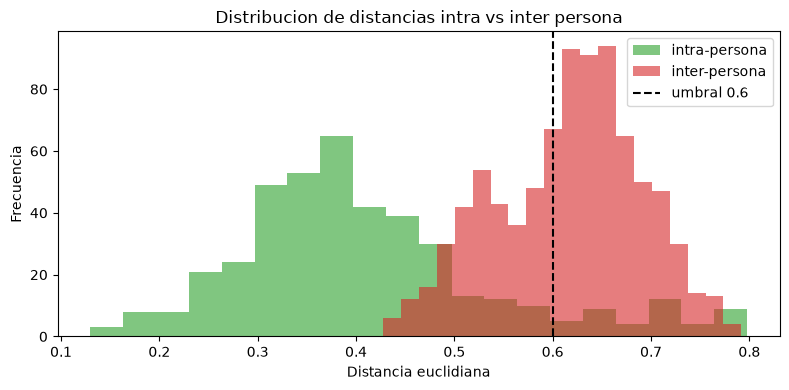

In [12]:
# Distribucion de distancias intra vs inter
plt.figure(figsize=(8, 4))
plt.hist(todas_intra, bins=20, alpha=0.6, color="tab:green", label="intra-persona")
plt.hist(todas_inter, bins=20, alpha=0.6, color="tab:red", label="inter-persona")
plt.axvline(0.6, color="black", linestyle="--", label="umbral 0.6")
plt.xlabel("Distancia euclidiana")
plt.ylabel("Frecuencia")
plt.title("Distribucion de distancias intra vs inter persona")
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_GRAPHS / "exp3_intra_inter_hist.png", dpi=120)
plt.show()

## 5. ¿Cuántas fotos bastan y conviene la variedad? (reconocimiento *held-out*)

La sección 4 mide qué tan parecidos son los embeddings entre sí, pero **no** responde directamente la pregunta práctica: *¿con cuántas fotos —y de qué tipo— queda bien registrada una persona?* Para eso usamos la métrica que de verdad importa: **reconocimiento de fotos no vistas**.

> **Cómo se cuenta el reconocimiento.** Cada rostro de prueba se compara contra el **centroide** (promedio de los embeddings) de cada persona y se considera reconocido si la distancia es menor que el umbral de referencia de **0.6** (el valor por defecto de face_recognition).

> Nota: el ratio inter/intra de la sección 4 **no** sirve para esto. Al agregar fotos variadas (perfil, contraluz, accesorios), las fotos de una misma persona se vuelven más distintas entre sí, así que la distancia intra *sube* y el ratio *baja* aunque el registro sea mejor. Por eso medimos reconocimiento, no el ratio.

### 5A. ¿Cuántas fotos bastan? (suficiencia)
Se registra a cada persona con **N fotos al azar** y se prueba con las **fotos restantes** (las que no se usaron para registrar). Una foto de prueba cuenta como **reconocida** si queda a menos de **0.6** del **centroide** de su propio registro (el promedio de las N fotos). Se promedia sobre 40 repeticiones con distintas fotos al azar (semilla fija para que sea reproducible).

In [ ]:
# Mapa archivo -> embedding, reaprovechando los embeddings ya calculados en la
# seccion 2 (sin recomputar YOLO). Como no hubo fallidas, el orden de las fotos
# exitosas coincide con el orden de embeddings_por_persona.
emb_por_archivo = {}
for carpeta in personas:
    nombre = carpeta.name
    sub = df_fotos[(df_fotos.persona == nombre) & (df_fotos.exito)]
    archivos_ok = list(sub.archivo)
    emb_por_archivo[nombre] = dict(zip(archivos_ok, embeddings_por_persona[nombre]))

nombres = list(emb_por_archivo.keys())
# Umbral de referencia = 0.6, el valor por defecto de face_recognition. Se usa
# para decidir cuando una foto de prueba se considera "reconocida"
# (distancia al centroide < umbral).
UMBRAL = 0.6


def dist(a, b):
    return float(np.linalg.norm(a - b))


def dist_centroide(v, galeria):
    """Distancia del embedding v al centroide (promedio) de un registro.

    Es el criterio que usa el reconocedor: se compara contra el promedio de los
    embeddings de cada persona (np.mean), no contra cada foto por separado.
    """
    centroide = np.mean(galeria, axis=0)
    return dist(v, centroide)


# --- 5A. Suficiencia: reconocer fotos NO usadas en el registro, segun N ---
N_REPETICIONES = 40
Ns = [2, 4, 6, 8, 10, 12]

filas_suf = []
for N in Ns:
    recalls, dists, rank1 = [], [], []
    for s in range(N_REPETICIONES):
        rng = np.random.default_rng(s)
        galerias, probes = {}, []
        valido = True
        for p in nombres:
            archivos = list(emb_por_archivo[p].keys())
            if len(archivos) <= N:        # hace falta al menos 1 foto de prueba
                valido = False
                break
            idx = rng.permutation(len(archivos))
            galerias[p] = [emb_por_archivo[p][archivos[i]] for i in idx[:N]]
            probes += [(p, emb_por_archivo[p][archivos[i]]) for i in idx[N:]]
        if not valido:
            continue
        for (p, v) in probes:
            d_propia = dist_centroide(v, galerias[p])
            dists.append(d_propia)
            recalls.append(1.0 if d_propia < UMBRAL else 0.0)
            # identidad: persona cuyo centroide queda mas cerca
            pred = min(nombres, key=lambda q: dist_centroide(v, galerias[q]))
            rank1.append(1.0 if pred == p else 0.0)
    filas_suf.append({
        "n_fotos": N,
        "reconocidas_<0.6_%": round(100 * np.mean(recalls), 1),
        "dist_media_a_registro": round(np.mean(dists), 3),
        "acierta_identidad_%": round(100 * np.mean(rank1), 1),
    })

df_suf = pd.DataFrame(filas_suf)
df_suf

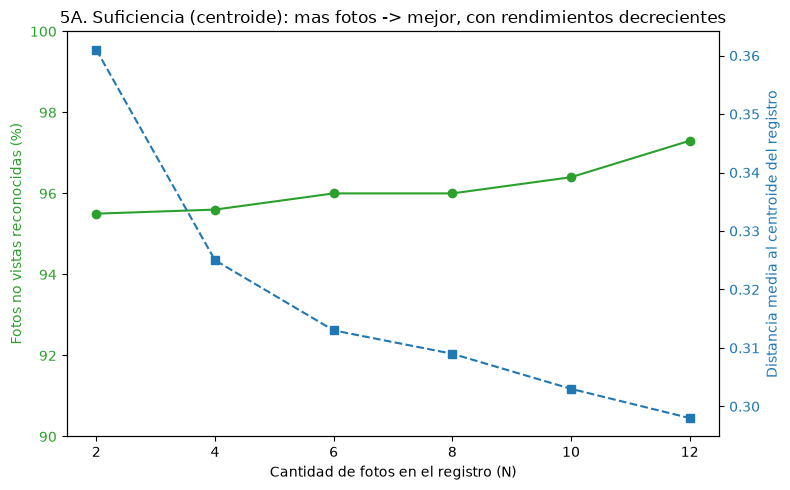

In [14]:
# Grafico 5A: reconocimiento de fotos no vistas vs cantidad de fotos de registro
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(df_suf.n_fotos, df_suf["reconocidas_<0.6_%"], "o-", color="tab:green",
         label="reconocidas (<0.6)")
ax1.set_xlabel("Cantidad de fotos en el registro (N)")
ax1.set_ylabel("Fotos no vistas reconocidas (%)", color="tab:green")
ax1.set_ylim(90, 100)
ax1.set_xticks(df_suf.n_fotos)
ax1.tick_params(axis="y", labelcolor="tab:green")

ax2 = ax1.twinx()
ax2.plot(df_suf.n_fotos, df_suf.dist_media_a_registro, "s--", color="tab:blue",
         label="distancia media al centroide")
ax2.set_ylabel("Distancia media al centroide del registro", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax1.set_title("5A. Suficiencia (centroide): mas fotos -> mejor, con rendimientos decrecientes")
fig.tight_layout()
plt.savefig(RUTA_GRAPHS / "exp3_suficiencia.png", dpi=120)
plt.show()

### 5B. ¿Conviene la variedad o basta con frontales?

Se registra a **gerardo** y **kevin** (las dos personas cuyas fotos indican la condición en el nombre) de dos formas, con el **mismo número de fotos**, y se prueban **las mismas caras difíciles que ninguna de las dos usó**:

- **Solo frontales:** 4 fotos frontales.
- **Variado:** 4 fotos de condiciones distintas (frontal, perfil, accesorio, luz lateral).

Cada registro se resume en su **centroide** (promedio de las 4 fotos) y la cara difícil se compara contra ese promedio. Si el centroide de solo frontales ya reconoce las caras difíciles (perfil, accesorios, contraluz), significa que para el **registro** no hace falta forzar variedad: el modelo de embeddings generaliza por su cuenta. (Miguel queda fuera porque sus fotos se llaman `foto1..15`, sin la condición.)

In [ ]:
# --- 5B. Frontal vs variado, para las personas con condiciones etiquetadas ---
# gerardo y kevin (miguel queda fuera: sus fotos foto1..15 no indican la condicion).
# Dos registros del mismo tamano (4 fotos) probados contra las MISMAS caras
# dificiles que ninguno de los dos uso para registrar.
GALERIAS_5B = {
    "gerardo": {
        "frontal": ["gerardo_frontal_01.jpg", "gerardo_frontal_02.jpg",
                    "gerardo_frontal_03.jpg", "gerardo_frontal_04.jpg"],
        "variado": ["gerardo_frontal_01.jpg", "gerardo_perfilDerecho_01.jpg",
                    "gerardo_accesorioCapucha_01.jpg", "gerardo_luzLateral_01.jpg"],
    },
    "kevin": {
        "frontal": ["foto1.jpg", "foto2.jpg", "foto3.jpg", "foto4.jpg"],
        "variado": ["foto1.jpg", "fotolat_der1.jpg", "fotocapucha.jpg", "fotoluzlateral1.jpg"],
    },
}


def evaluar_variedad(persona, gal_frontal, gal_variado):
    """Compara dos registros (frontal vs variado) de una persona sobre sus
    fotos no usadas. Devuelve un DataFrame con una fila por foto de prueba.

    Cada registro se resume en su centroide (promedio de sus embeddings): la cara
    dificil se compara contra ese promedio y se considera reconocida si la
    distancia es menor que UMBRAL (0.6 de referencia).
    """
    g = emb_por_archivo[persona]
    usados = set(gal_frontal) | set(gal_variado)
    probes = [a for a in g if a not in usados]
    galF = [g[a] for a in gal_frontal]
    galV = [g[a] for a in gal_variado]
    filas = []
    for a in probes:
        dF = dist_centroide(g[a], galF)
        dV = dist_centroide(g[a], galV)
        filas.append({
            "persona": persona,
            "foto_dificil": a.replace(f"{persona}_", "").replace(".jpg", ""),
            "dist_solo_frontal": round(dF, 3),
            "dist_variado": round(dV, 3),
            "recon_frontal": "OK" if dF < UMBRAL else "NO",
            "recon_variado": "OK" if dV < UMBRAL else "NO",
        })
    return pd.DataFrame(filas)


df_var = pd.concat(
    [evaluar_variedad(p, GALERIAS_5B[p]["frontal"], GALERIAS_5B[p]["variado"])
     for p in GALERIAS_5B],
    ignore_index=True,
)

# Resumen por persona
print("Caras dificiles reconocidas (<0.6, centroide) segun como se registro:")
for p in GALERIAS_5B:
    sub = df_var[df_var.persona == p]
    nF = int((sub.recon_frontal == "OK").sum())
    nV = int((sub.recon_variado == "OK").sum())
    print(f"  {p:8s}: solo frontal {nF}/{len(sub)} (dist media {sub.dist_solo_frontal.mean():.3f}) | "
          f"variado {nV}/{len(sub)} (dist media {sub.dist_variado.mean():.3f})")

# Grafico 5B: un subplot por persona, distancia de cada cara dificil a cada registro
fig, axes = plt.subplots(1, len(GALERIAS_5B), figsize=(13, 4.5), sharey=True)
for ax, p in zip(np.atleast_1d(axes), GALERIAS_5B):
    sub = df_var[df_var.persona == p].reset_index(drop=True)
    x = np.arange(len(sub))
    w = 0.4
    ax.bar(x - w / 2, sub.dist_solo_frontal, w, label="solo frontales", color="tab:orange")
    ax.bar(x + w / 2, sub.dist_variado, w, label="variado", color="tab:blue")
    ax.axhline(UMBRAL, color="black", ls="--", label="umbral 0.6")
    ax.set_xticks(x)
    ax.set_xticklabels(sub.foto_dificil, rotation=90, fontsize=7)
    ax.set_title(p)
axes[0].set_ylabel("Distancia al centroide del registro")
axes[0].legend(fontsize=8)
fig.suptitle("5B. Reconocer caras dificiles segun como se registro (frontal vs variado)")
fig.tight_layout()
plt.savefig(RUTA_GRAPHS / "exp3_variedad.png", dpi=120)
plt.show()

df_var

## 6. Guardar resultados (CSV)

In [16]:
# Guardar todos los resultados a CSV
RUTA_CSV = RAIZ / "experiments" / "resultados_exp3.csv"
RUTA_CSV_SUF = RAIZ / "experiments" / "resultados_exp3_suficiencia.csv"
RUTA_CSV_VAR = RAIZ / "experiments" / "resultados_exp3_variedad.csv"
RUTA_CSV_FOTOS = RAIZ / "experiments" / "resultados_exp3_por_foto.csv"

df_tiempos.to_csv(RUTA_CSV, index=False, encoding="utf-8")
df_suf.to_csv(RUTA_CSV_SUF, index=False, encoding="utf-8")
df_var.to_csv(RUTA_CSV_VAR, index=False, encoding="utf-8")
df_fotos.to_csv(RUTA_CSV_FOTOS, index=False, encoding="utf-8")

print("Resultados guardados:")
for r in (RUTA_CSV, RUTA_CSV_SUF, RUTA_CSV_VAR, RUTA_CSV_FOTOS):
    print(" -", r)

Resultados guardados:
 - c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\experiments\resultados_exp3.csv
 - c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\experiments\resultados_exp3_suficiencia.csv
 - c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\experiments\resultados_exp3_variedad.csv
 - c:\Users\Gerardo\unmsm\7timo ciclo\IA\sistema-control-asistencia-facial\experiments\resultados_exp3_por_foto.csv


## 7. Interpretación y conclusiones

> **Nota de método.** El reconocimiento de las secciones 5A y 5B se mide comparando cada rostro contra el **centroide** (promedio de los embeddings) de cada persona —el mismo criterio que emplea el reconocedor— y se cuenta como reconocido cuando la distancia es menor que el umbral de referencia de **0.6**, el valor por defecto de face_recognition.

**Rendimiento del registro (sección 3).** Las 51 fotos se procesaron con **100% de éxito** (0 fallidas) en **31.97 s**, es decir **~627 ms por foto**. El registro es un proceso *offline* —se ejecuta una sola vez al dar de alta al personal— y su costo, dominado por la inferencia de YOLO y la extracción del embedding con dlib, es irrelevante para la operación en tiempo real.

**Calidad de la base (sección 4).** La distancia media **intra-persona (0.41)** es menor que la **inter-persona (0.62)**, con un ratio de separación de **1.50×**, de modo que la base distingue a las personas. No obstante:
- Las distribuciones se solapan entre ~0.43 y ~0.60, y el par más confundible es **gerardo–kevin**, con distancia media **0.54**.
- Ese solapamiento muestra que el umbral 0.6 por defecto es **permisivo** para esta base; el punto de separación natural está cerca de **~0.5**. Conviene, por tanto, fijar el umbral del reconocedor mediante un análisis dedicado de FAR/FRR en lugar de conservar el valor por defecto.

**¿Cuántas fotos bastan? (sección 5A).** El reconocimiento de fotos no vistas crece con N pero con rendimientos decrecientes:

| N fotos | reconocidas (<0.6) | distancia media al centroide |
|:--:|:--:|:--:|
| 2 | 95.5% | 0.361 |
| 6 | 96.0% | 0.313 |
| 10 | 96.4% | 0.303 |
| 12 | 97.3% | 0.298 |

Ya con **2 fotos** se reconoce el ~95.5%, y a partir de **~10** la mejora es marginal (de 10 a 12 fotos el recall sube alrededor de un punto). La identificación de la persona correcta se mantiene en torno al **95%** en todo el rango, y la distancia media al centroide baja de 0.36 a 0.30 conforme se agregan fotos, lo que refleja un registro cada vez más estable. Conclusión: **no es necesario acumular muchas fotos**; alrededor de 10 dejan el registro prácticamente saturado.

**¿Conviene la variedad? (sección 5B).** Registrando con **solo 4 frontales** se reconocieron **todas** las caras difíciles de ambas personas: **gerardo 8/8** (distancia media 0.33) y **kevin 14/14** (0.32), es decir **22/22 en total**, todas por debajo de 0.6. El caso más extremo, el perfil izquierdo de Kevin, alcanza **0.558** y aun así queda dentro del umbral. La diferencia frente al registro variado es **mixta y mínima**: en gerardo el registro frontal da distancias algo menores que el variado, y en kevin ocurre lo contrario, sin una ventaja consistente para ninguno. Esto confirma que el modelo de embeddings (dlib ResNet) es **robusto** a pose, iluminación y accesorios, por lo que para el registro bastan unas pocas frontales limpias.

### Conclusión
1. El **registro es barato y confiable**: 100% de éxito y proceso offline (~627 ms por foto).
2. La base **separa a las personas** (ratio 1.50×), pero con solapamiento cerca de 0.6, lo que indica que el umbral por defecto es permisivo y conviene calibrarlo para esta base.
3. Para el **registro bastan ~10 fotos** (mínimo aceptable ~5); más allá de ese punto la ganancia es marginal.
4. **No es necesario forzar variedad** en el registro: el modelo generaliza desde frontales limpias (22/22 caras difíciles reconocidas). La variedad resulta útil para poner a prueba el sistema, no para construir el registro.

> Los resultados completos quedan en `resultados_exp3.csv` (tiempos), `resultados_exp3_suficiencia.csv`, `resultados_exp3_variedad.csv` y en los gráficos de `experiments/graphs/`.